[0.14558498 0.00352714 0.99714843]


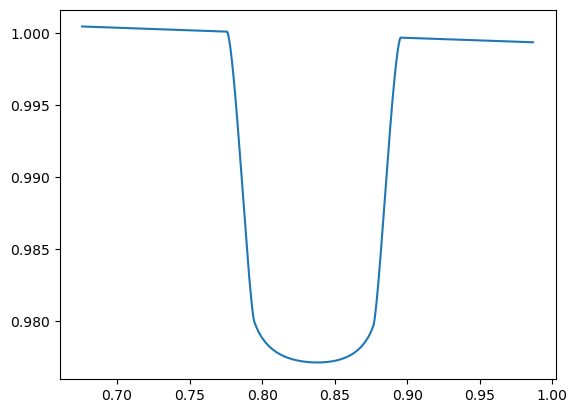

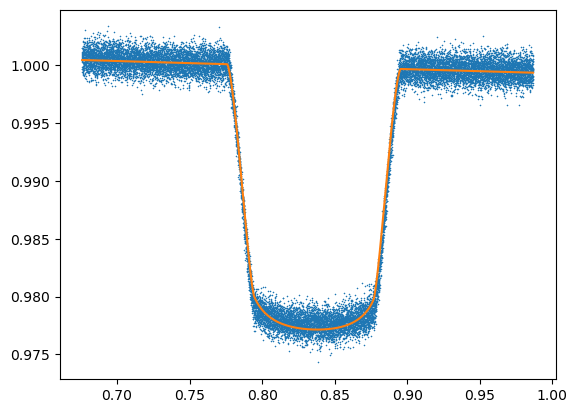

0.14558498

In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from fitting import fit
from fitting import bat
from fitting import bat_lin
from fitting import setu
import math
time_frame = []
fluxes = []
with (open("time.pickle", "rb")) as openfile:
    while True:
        try:
            time_frame.append(pickle.load(openfile))
        except EOFError:
            break

with (open("WL_flux.pickle", "rb")) as openfile:
    while True:
        try:
            fluxes.append(pickle.load(openfile))
        except EOFError:
            break

# print(len(fluxes[0]), len(time_frame[0]) )

# plt.plot( time_frame[0],fluxes[0], 'x', markersize = 0.5)
#just to get rid of nans from fluxes
ind = []
for n,f in enumerate(fluxes[0]):
    if math.isnan(f):
        ind.append(n)

new_time_frame = time_frame[0] - int(time_frame[0][0])
new_fluxes = np.delete(fluxes[0], ind)
new_time_frame = np.delete(new_time_frame, ind)


for i in new_fluxes:
    if math.isnan(i):
        print(i)
#
setu([0.1, 0.3])
g = [0.14558498, 0.00352714, 0.99714843]
popt, pcov = fit(bat_lin,new_time_frame, new_fluxes, guesses= g)
print(popt)

plt.plot(new_time_frame, bat_lin(new_time_frame, *g))
plt.show()
plt.plot(new_time_frame, new_fluxes, 'x', markersize = 0.5)
plt.plot(new_time_frame, bat_lin(new_time_frame, *popt))
plt.show()



0.14558498

0.775792618340347
0.8954958116810303
7400
0.7944304761622334
12551
0.8768579547904665


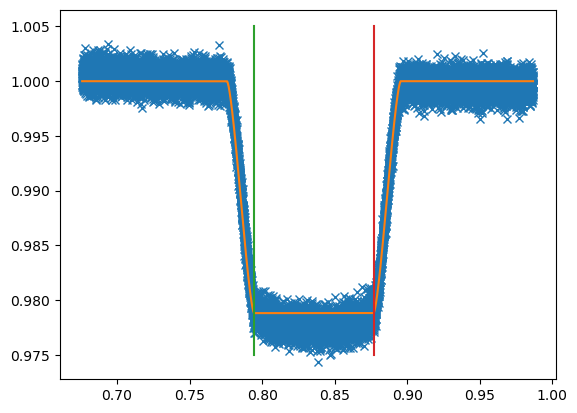

In [27]:
setu([0, 0])
fluxes = bat(new_time_frame, g[0])

plt.plot(new_time_frame, new_fluxes, 'x')
plt.plot(new_time_frame, fluxes)

diffs = np.diff(fluxes)
for n, i in enumerate(diffs):
    if i < 0:
        print(new_time_frame[n - 1])
        start = n
        break

for n, i in enumerate(reversed(diffs)):
    if i > 0:
        nTrue = len(diffs) - n
        print(new_time_frame[nTrue + 1])
        end = nTrue
        break


for n, i in enumerate(diffs[start:]):
    if i == 0:
        startnTrue = n + start
        start_full = new_time_frame[startnTrue]
        print(startnTrue)
        print(start_full)
        break

for n, i in enumerate(diffs[(startnTrue + 1):]):
    if i > 0:
        endnTrue = n + startnTrue + 1
        end_full = new_time_frame[endnTrue]
        print(endnTrue)
        print(end_full)
        break

x = [start_full, start_full]
y = [0.975, 1.005]
plt.plot(x, y)
x = [end_full, end_full]
plt.plot(x,y)